In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [3]:
# Load SST NetCDF file
ds = xr.open_dataset("sst.day.mean.1990.nc")   # change filename if needed

sst = ds['sst']


In [4]:
bob = sst.sel(
    lat=slice(5, 25),
    lon=slice(80, 100)
)


In [5]:
arabian = sst.sel(
    lat=slice(5, 25),
    lon=slice(50, 80)
)


In [6]:
# Pre-monsoon (MAM)
sst_mam = bob.sel(time=bob['time.month'].isin([3, 4, 5]))

# Monsoon (JJAS)
sst_jjas = bob.sel(time=bob['time.month'].isin([6, 7, 8, 9]))

# Post-monsoon (ON)
sst_on = bob.sel(time=bob['time.month'].isin([10, 11]))


In [7]:
mam_mean = sst_mam.mean(dim='time')
jjas_mean = sst_jjas.mean(dim='time')
on_mean = sst_on.mean(dim='time')


In [8]:
def plot_sst(data, title, vmin, vmax):
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='YlOrRd',
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={'label': 'SST (°C)'}
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_title(title)
    plt.show()


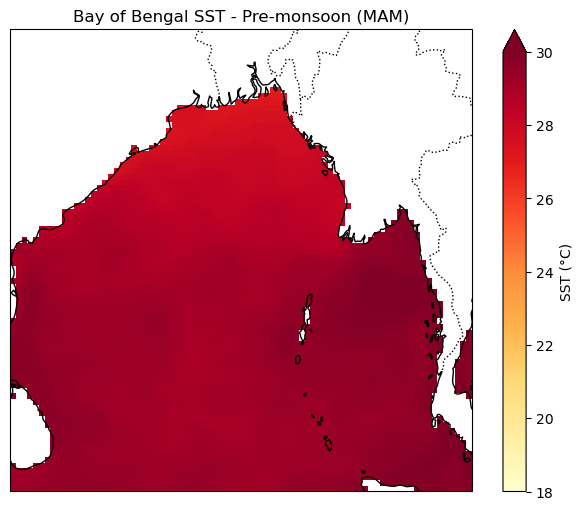

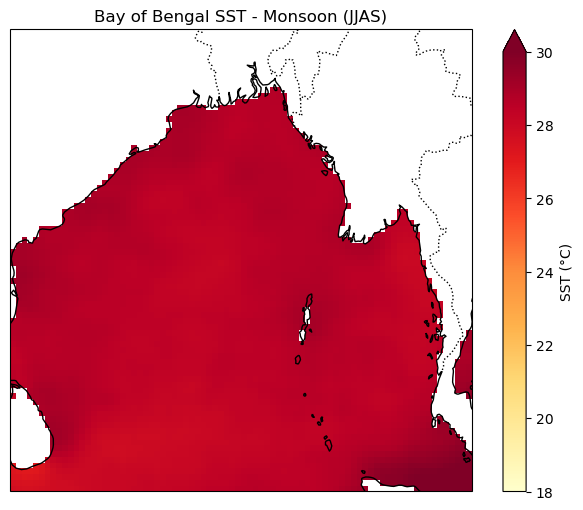

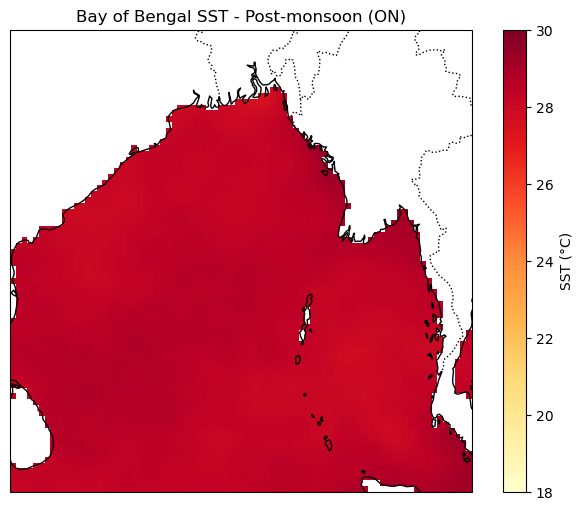

In [9]:
vmin = 18
vmax = 30

plot_sst(mam_mean, "Bay of Bengal SST - Pre-monsoon (MAM)", vmin, vmax)
plot_sst(jjas_mean, "Bay of Bengal SST - Monsoon (JJAS)", vmin, vmax)
plot_sst(on_mean, "Bay of Bengal SST - Post-monsoon (ON)", vmin, vmax)


/home/arif/miniconda3/envs/arif_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


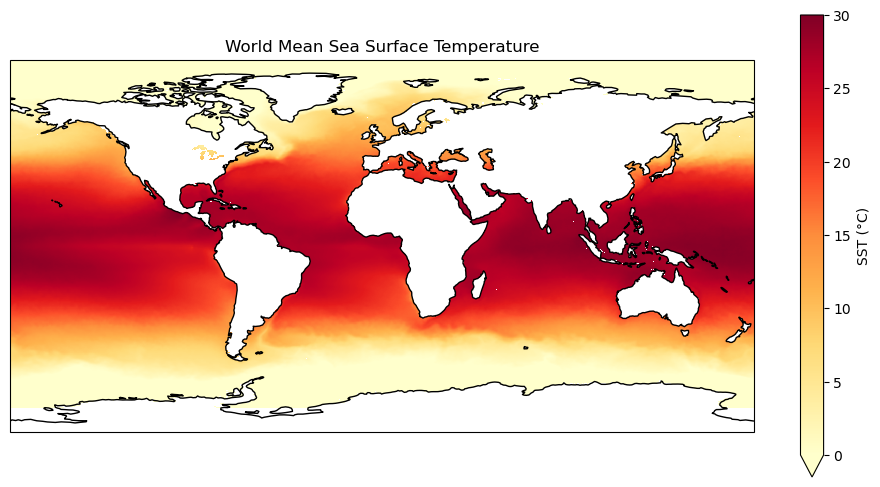

In [10]:
world_mean = sst.mean(dim='time')

plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

world_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd',
    vmin=0,
    vmax=30,
    cbar_kwargs={'label': 'SST (°C)'}
)

ax.coastlines()
ax.set_title("World Mean Sea Surface Temperature")
plt.show()


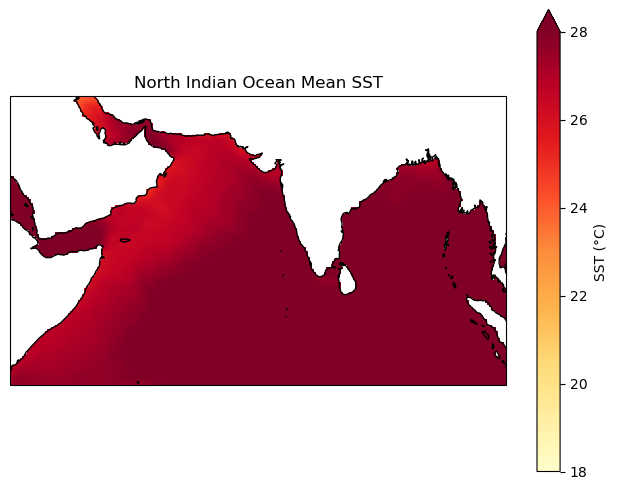

In [11]:
nio = sst.sel(
    lat=slice(-5, 30),
    lon=slice(40, 100)
).mean(dim='time')

plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

nio.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd',
    vmin=18,
    vmax=28,
    cbar_kwargs={'label': 'SST (°C)'}
)

ax.coastlines()
ax.set_title("North Indian Ocean Mean SST")
plt.show()
